# Day-Ahead 24-Hour Forecasting at 15-Minute Granularity (TFT)

This notebook performs **multi-step forecasting** for electricity price at **15-minute resolution**.

- Horizon: **24 hours = 96 steps**
- Uses past unknowns (price/demand) and known future covariates (weather + calendar).

## 1) Install dependencies (only if needed)
Run once if imports fail, then restart kernel.

In [1]:
%pip install -q pytorch-forecasting lightning holidays

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings
from datetime import datetime
from pathlib import Path

import holidays
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore")
pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision("medium")

c:\Users\rkale\miniconda3\envs\summer\lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


In [3]:
PROJECT_ROOT = Path.cwd().parent.parent.parent.parent
PRICE_PATH = PROJECT_ROOT / "data" / "price_data.csv"
WEATHER_PATH = PROJECT_ROOT / "data" / "historical_hourly_2023_2025.csv"
OUTPUT_PATH = PROJECT_ROOT / "Prediction" / "tft_day_ahead_24h_15min.csv"
WEATHER_DAILY = PROJECT_ROOT / "data" / "historical_daily_2023_2025.csv"

# 15-minute base series
price_df = pd.read_csv(PRICE_PATH)
ts_col = "timestamp" if "timestamp" in price_df.columns else "Timestamp"
price_df[ts_col] = pd.to_datetime(price_df[ts_col], utc=True, errors="coerce").dt.tz_convert(None)
price_df = price_df.rename(columns={ts_col: "Timestamp"})
price_df = price_df.sort_values("Timestamp").drop_duplicates("Timestamp")

base_cols = [c for c in ["Timestamp", "price", "demand_itsdo", "demand_indo", "demand_inddem", "demand_forecast", "wind_generation", "solar_generation", "margin_daily_forecast"] if c in price_df.columns]
price_df = price_df[base_cols]

full_index = pd.date_range(price_df["Timestamp"].min(), price_df["Timestamp"].max(), freq="15min")
price_df = price_df.set_index("Timestamp").reindex(full_index).rename_axis("Timestamp").reset_index()

# Hourly weather converted to smooth 15-minute weather by time interpolation
weather_df = pd.read_csv(WEATHER_PATH)
w_ts = "Timestamp" if "Timestamp" in weather_df.columns else "timestamp_utc"
weather_df[w_ts] = pd.to_datetime(weather_df[w_ts], utc=True, errors="coerce").dt.tz_convert(None)
weather_df = weather_df.rename(columns={w_ts: "WeatherTimestamp"}).sort_values("WeatherTimestamp")

hourly_keep = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "precipitation", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "shortwave_radiation", "direct_radiation",
    "wind_speed_10m", "wind_gusts_10m", "wind_direction_10m",
    "surface_pressure", "weather_code"
]
hourly_keep = [c for c in hourly_keep if c in weather_df.columns]
weather_df = weather_df[["WeatherTimestamp"] + hourly_keep]

weather_df = weather_df.set_index("WeatherTimestamp")
weather_15min_index = pd.date_range(price_df["Timestamp"].min(), price_df["Timestamp"].max(), freq="15min")
weather_15min = weather_df.reindex(weather_15min_index)

numeric_weather_cols = [c for c in weather_15min.columns if c != "weather_code"]
if numeric_weather_cols:
    weather_15min[numeric_weather_cols] = weather_15min[numeric_weather_cols].interpolate(
        method="time", limit_direction="both"
    )

if "weather_code" in weather_15min.columns:
    weather_15min["weather_code"] = weather_15min["weather_code"].ffill().bfill()

weather_15min = weather_15min.reset_index().rename(columns={"index": "Timestamp"})
df = price_df.merge(weather_15min, on="Timestamp", how="left")

# Daily weather/sun features -> 15-minute features (ETL-style Solar_intensity + daily numeric vars)
daily_df = pd.read_csv(WEATHER_DAILY)
d_ts = "date_utc" if "date_utc" in daily_df.columns else "Timestamp"
daily_df[d_ts] = pd.to_datetime(daily_df[d_ts], utc=True, errors="coerce").dt.tz_convert(None)
daily_df = daily_df.rename(columns={d_ts: "Timestamp"}).sort_values("Timestamp")

if {"sunrise", "daylight_duration"}.issubset(daily_df.columns):
    sunrise = pd.to_datetime(daily_df["sunrise"], errors="coerce").dt.tz_localize(None)
    day_length_hours = daily_df["daylight_duration"] / 3600.0
    safe_day_length = day_length_hours.replace(0, np.nan)
    solar_noon_dt = sunrise + pd.to_timedelta(day_length_hours / 2, unit="h")
    hours = (daily_df["Timestamp"] - solar_noon_dt) / np.timedelta64(1, "h")
    daily_df["Solar_intensity"] = np.maximum(0, np.cos(hours * np.pi / safe_day_length)).fillna(0.0)

excluded_daily_cols = {"Timestamp", "sunrise", "sunset", "daylight_duration", "sunshine_duration"}
daily_numeric = [c for c in daily_df.columns if c not in excluded_daily_cols and pd.api.types.is_numeric_dtype(daily_df[c])]

daily_features = daily_df[["Timestamp"] + daily_numeric].drop_duplicates("Timestamp")
daily_features = daily_features.set_index("Timestamp")
daily_15min = daily_features.reindex(weather_15min_index).ffill().bfill().reset_index()
daily_15min = daily_15min.rename(columns={"index": "Timestamp"})

df = df.merge(daily_15min, on="Timestamp", how="left")

# Fill numeric gaps (demand / residual missing values)
for col in df.columns:
    if col == "Timestamp":
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].interpolate(limit_direction="both").ffill().bfill()

# filter the dataset to 2025
df = df[df["Timestamp"]> "2025-01-01"]

df = df.dropna(subset=["Timestamp", "price"]).sort_values("Timestamp").reset_index(drop=True)


print(f"Rows: {len(df):,}")
print(f"Range: {df['Timestamp'].min()} -> {df['Timestamp'].max()}")
print("Daily-derived features:", [c for c in ["Solar_intensity"] + daily_numeric if c in df.columns])
display(df.head(3))

Rows: 40,571
Range: 2025-01-01 00:15:00 -> 2026-02-27 14:45:00
Daily-derived features: ['Solar_intensity', 'shortwave_radiation_sum', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours', 'temperature_2m_max', 'temperature_2m_min', 'Solar_intensity']


,Timestamp,price,demand_itsdo,demand_indo,demand_inddem,demand_forecast,wind_generation,solar_generation,margin_daily_forecast,temperature_2m,...,weather_code_x,weather_code_y,shortwave_radiation_sum,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,temperature_2m_max,temperature_2m_min,Solar_intensity
0,2025-01-01 00:15:00,9.07,26483.0,20949.0,-173.0,20900.0,20557.559,0.0,19370.0,6.4875,...,61.0,61.0,1.57,10.400001,10.400001,0.0,17.0,6.6,-2.85,0.492076
1,2025-01-01 00:30:00,23.51,26474.0,21129.0,-2338.0,20900.0,20108.433,0.0,19370.0,6.5250,...,61.0,61.0,1.57,10.400001,10.400001,0.0,17.0,6.6,-2.85,0.492076
2,2025-01-01 00:45:00,23.51,26474.0,21129.0,-2338.0,20900.0,20108.433,0.0,19370.0,6.5625,...,61.0,61.0,1.57,10.400001,10.400001,0.0,17.0,6.6,-2.85,0.492076


In [4]:
# 15-minute calendar features (known in the future)

uk_holidays = holidays.CountryHoliday("UK")
df["hour"] = df["Timestamp"].dt.hour.astype(str)
df["quarter_hour"] = (df["Timestamp"].dt.minute // 15).astype(str)
df["quarter_of_day"] = ((df["Timestamp"].dt.hour * 60 + df["Timestamp"].dt.minute) // 15).astype(str)
df["day_of_week"] = df["Timestamp"].dt.dayofweek.astype(str)
df["is_weekend"] = (df["Timestamp"].dt.dayofweek >= 5).astype(str)
df["is_holiday"] = df["Timestamp"].dt.date.isin(uk_holidays).astype(str)
df["is_working_day"] = ((df["is_weekend"] == "False") & (df["is_holiday"] == "False")).astype(str)

# Cyclical known reals
minute_of_day = df["Timestamp"].dt.hour * 60 + df["Timestamp"].dt.minute
df["tod_sin"] = np.sin(2 * np.pi * minute_of_day / 1440.0)
df["tod_cos"] = np.cos(2 * np.pi * minute_of_day / 1440.0)
df["dow_sin"] = np.sin(2 * np.pi * df["Timestamp"].dt.dayofweek / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * df["Timestamp"].dt.dayofweek / 7.0)

# Time series ids
df["series_id"] = "GB"
df["time_idx"] = np.arange(len(df), dtype=np.int64)

MAX_PREDICTION_LENGTH = 96   # 24h * 4 steps/hour
MAX_ENCODER_LENGTH = 288     # 72h lookback at 15-min

known_weather = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "precipitation", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "shortwave_radiation", "direct_radiation",
    "wind_speed_10m", "wind_gusts_10m", "wind_direction_10m",
    "surface_pressure", "Solar_intensity"
]
price_known_reals = ["demand_itsdo","demand_indo","demand_inddem","demand_forecast","wind_generation","solar_generation","margin_daily_forecast"]
daily_known_reals = [c for c in daily_numeric if c in df.columns and c != "price"] if "daily_numeric" in globals() else []
known_reals = [c for c in known_weather if c in df.columns] + daily_known_reals + ["tod_sin", "tod_cos", "dow_sin", "dow_cos"] + price_known_reals
known_reals = list(dict.fromkeys(known_reals))

known_categoricals = [
    c
    for c in ["hour", "quarter_hour", "quarter_of_day", "day_of_week", "is_weekend", "is_holiday", "is_working_day"]
    if c in df.columns
]
unknown_reals = [c for c in ["price"] if c in df.columns]

test_steps = 7 * 24 * 4
val_steps = 7 * 24 * 4
train_cutoff = df.time_idx.max() - (val_steps + test_steps + MAX_PREDICTION_LENGTH)
val_start = train_cutoff + 1
test_start = df.time_idx.max() - (test_steps + MAX_PREDICTION_LENGTH) + 1

print("Known real covariates:", known_reals)
print("Known categorical covariates:", known_categoricals)
print("Unknown real covariates:", unknown_reals)
print(f"train_cutoff={train_cutoff}, val_start={val_start}, test_start={test_start}")

Known real covariates: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'wind_speed_10m', 'wind_gusts_10m', 'wind_direction_10m', 'surface_pressure', 'Solar_intensity', 'shortwave_radiation_sum', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours', 'temperature_2m_max', 'temperature_2m_min', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'demand_itsdo', 'demand_indo', 'demand_inddem', 'demand_forecast', 'wind_generation', 'solar_generation', 'margin_daily_forecast']
Known categorical covariates: ['hour', 'quarter_hour', 'quarter_of_day', 'day_of_week', 'is_weekend', 'is_holiday', 'is_working_day']
Unknown real covariates: ['price']
train_cutoff=39130, val_start=39131, test_start=39803


In [5]:
training = TimeSeriesDataSet(
    df[df.time_idx <= train_cutoff],
    time_idx="time_idx",
    target="price",
    group_ids=["series_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_known_reals=known_reals,
    time_varying_known_categoricals=known_categoricals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=["series_id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training, df, min_prediction_idx=val_start, stop_randomization=True
)
test_set = TimeSeriesDataSet.from_dataset(
    training, df, min_prediction_idx=test_start, stop_randomization=True
)

batch_size = 256
train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
test_loader = test_set.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"Train windows: {len(training):,} | Val windows: {len(validation):,} | Test windows: {len(test_set):,}")

Train windows: 38,748 | Val windows: 1,345 | Test windows: 673


In [6]:
early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=8, mode="min")
checkpoint_dir = PROJECT_ROOT / "models" / "price_prediction" / "tft_day_ahead_15min"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    dirpath=checkpoint_dir,
    filename="tft-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    save_last=True,
 )

trainer = pl.Trainer(
    max_epochs=40,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, checkpoint_cb],
    enable_checkpointing=True,
    logger=False
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4
)

print(f"Model params: {tft.size()/1e3:.1f}k")
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

BEST_CHECKPOINT_PATH = checkpoint_cb.best_model_path
LAST_CHECKPOINT_PATH = checkpoint_cb.last_model_path
print("Best checkpoint:", BEST_CHECKPOINT_PATH)
print("Last checkpoint:", LAST_CHECKPOINT_PATH)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Model params: 244.7k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  2.3 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.3 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 93.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 91.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 244 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 244 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1328                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Best checkpoint: C:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\models\price_prediction\tft_day_ahead_15min\tft-epoch=01-val_loss=5.6908-v1.ckpt
Last checkpoint: C:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\models\price_prediction\tft_day_ahead_15min\last-v2.ckpt


In [7]:
# Reload model later from checkpoint (run this in a new session after imports)
CKPT_TO_LOAD = BEST_CHECKPOINT_PATH or LAST_CHECKPOINT_PATH
if not CKPT_TO_LOAD:
    raise ValueError("No checkpoint path found. Train first or set CKPT_TO_LOAD manually.")

loaded_tft = TemporalFusionTransformer.load_from_checkpoint(CKPT_TO_LOAD)
loaded_tft.eval()
print("Loaded checkpoint:", CKPT_TO_LOAD)

Loaded checkpoint: C:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\models\price_prediction\tft_day_ahead_15min\tft-epoch=01-val_loss=5.6908-v1.ckpt


In [8]:
# Save run metadata for reproducible inference
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
metadata_path = checkpoint_dir / f"run_metadata_{run_id}.json"
latest_metadata_path = checkpoint_dir / "latest_run_metadata.json"

run_metadata = {
    "run_id": run_id,
    "project_root": str(PROJECT_ROOT),
    "checkpoint_dir": str(checkpoint_dir),
    "best_checkpoint_path": BEST_CHECKPOINT_PATH,
    "last_checkpoint_path": LAST_CHECKPOINT_PATH,
    "model_class": "TemporalFusionTransformer",
    "max_prediction_length": int(MAX_PREDICTION_LENGTH),
    "max_encoder_length": int(MAX_ENCODER_LENGTH),
    "known_reals": known_reals,
    "known_categoricals": known_categoricals,
    "unknown_reals": unknown_reals,
    "train_cutoff": int(train_cutoff),
    "val_start": int(val_start),
    "test_start": int(test_start),
    "timestamp_min": str(df["Timestamp"].min()),
    "timestamp_max": str(df["Timestamp"].max()),
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)
with open(latest_metadata_path, "w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)

print("Saved metadata:", metadata_path)
print("Updated latest metadata:", latest_metadata_path)

Saved metadata: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\models\price_prediction\tft_day_ahead_15min\run_metadata_20260228_015408.json
Updated latest metadata: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\models\price_prediction\tft_day_ahead_15min\latest_run_metadata.json


In [9]:
def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100

    # Metric requested: %ŷ - %y (signed percent error)
    pct_error = ((y_pred - y_true) / np.clip(np.abs(y_true), 1e-6, None)) * 100
    pct_error_mean = float(np.mean(pct_error))
    pct_error_median = float(np.median(pct_error))

    # Percent change metrics
    actual_pct_change = (np.diff(y_true) / np.clip(np.abs(y_true[:-1]), 1e-6, None)) * 100
    pred_pct_change = (np.diff(y_pred) / np.clip(np.abs(y_pred[:-1]), 1e-6, None)) * 100
    pct_change_mae = float(np.mean(np.abs(pred_pct_change - actual_pct_change))) if len(actual_pct_change) else np.nan
    actual_pct_change_mean = float(np.mean(actual_pct_change)) if len(actual_pct_change) else np.nan
    pred_pct_change_mean = float(np.mean(pred_pct_change)) if len(pred_pct_change) else np.nan

    # Directional accuracy / hit rates
    actual_up = actual_pct_change > 0
    actual_down = actual_pct_change < 0
    pred_up = pred_pct_change > 0
    pred_down = pred_pct_change < 0

    dir_match = np.sign(actual_pct_change) == np.sign(pred_pct_change)
    directional_accuracy = float(np.mean(dir_match)) if len(dir_match) else np.nan

    up_den = int(pred_up.sum())
    down_den = int(pred_down.sum())
    hit_rate_up = float((actual_up & pred_up).sum() / up_den) if up_den > 0 else np.nan
    hit_rate_down = float((actual_down & pred_down).sum() / down_den) if down_den > 0 else np.nan

    # Spike prediction metrics (on absolute percent change)
    if len(actual_pct_change):
        spike_threshold = float(np.percentile(np.abs(actual_pct_change), 95))
        true_spike = np.abs(actual_pct_change) >= spike_threshold
        pred_spike = np.abs(pred_pct_change) >= spike_threshold

        tp = int((true_spike & pred_spike).sum())
        fp = int((~true_spike & pred_spike).sum())
        fn = int((true_spike & ~pred_spike).sum())

        spike_precision = float(tp / (tp + fp)) if (tp + fp) > 0 else np.nan
        spike_recall = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
        spike_f1 = (
            float(2 * spike_precision * spike_recall / (spike_precision + spike_recall))
            if (spike_precision == spike_precision and spike_recall == spike_recall and (spike_precision + spike_recall) > 0)
            else np.nan
        )
    else:
        spike_threshold = np.nan
        spike_precision = np.nan
        spike_recall = np.nan
        spike_f1 = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE(%)": mape,
        "PctErrorMean(%ŷ-%y)": pct_error_mean,
        "PctErrorMedian(%ŷ-%y)": pct_error_median,
        "PctChangeMAE": pct_change_mae,
        "ActualPctChangeMean": actual_pct_change_mean,
        "PredPctChangeMean": pred_pct_change_mean,
        "DirectionalAccuracy": directional_accuracy,
        "HitRateUp": hit_rate_up,
        "HitRateDown": hit_rate_down,
        "SpikeThresholdAbsPctChg": spike_threshold,
        "SpikePrecision": spike_precision,
        "SpikeRecall": spike_recall,
        "SpikeF1": spike_f1,
    }

raw_val, x_val, *_ = tft.predict(val_loader, mode="raw", return_x=True)
val_pred = raw_val["prediction"][:, :, 3].detach().cpu().numpy()
val_true = x_val["decoder_target"].detach().cpu().numpy()

raw_test, x_test, *_ = tft.predict(test_loader, mode="raw", return_x=True)
test_pred = raw_test["prediction"][:, :, 3].detach().cpu().numpy()
test_true = x_test["decoder_target"].detach().cpu().numpy()

print("Validation (96-step trajectories):")
for k, v in metrics(val_true, val_pred).items():
    print(f"  {k}: {v:.4f}" if isinstance(v, (float, np.floating)) else f"  {k}: {v}")

print("\nTest (96-step trajectories):")
for k, v in metrics(test_true, test_pred).items():
    print(f"  {k}: {v:.4f}" if isinstance(v, (float, np.floating)) else f"  {k}: {v}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

Validation (96-step trajectories):
  MAE: 10.8829
  RMSE: 14.8600
  MAPE(%): 39.8626
  PctErrorMean(%ŷ-%y): 36.2244
  PctErrorMedian(%ŷ-%y): 8.7155
  PctChangeMAE: 4.9408
  ActualPctChangeMean: 1.3656
  PredPctChangeMean: 0.1038
  DirectionalAccuracy: 0.3322
  HitRateUp: 0.3001
  HitRateDown: 0.3641
  SpikeThresholdAbsPctChg: 14.0685
  SpikePrecision: 0.7677
  SpikeRecall: 0.1950
  SpikeF1: 0.3110

Test (96-step trajectories):
  MAE: 14.6524
  RMSE: 18.9871
  MAPE(%): 70.5235
  PctErrorMean(%ŷ-%y): 66.1689
  PctErrorMedian(%ŷ-%y): 14.0734
  PctChangeMAE: 7.9857
  ActualPctChangeMean: 2.6641
  PredPctChangeMean: 0.1829
  DirectionalAccuracy: 0.3157
  HitRateUp: 0.2721
  HitRateDown: 0.3608
  SpikeThresholdAbsPctChg: 22.7922
  SpikePrecision: 0.6340
  SpikeRecall: 0.1288
  SpikeF1: 0.2141


In [10]:
# Predict next 24h at 15-minute resolution (96 steps)
predict_ds = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)
predict_loader = predict_ds.to_dataloader(train=False, batch_size=1, num_workers=0)
raw_next, _, *_ = tft.predict(predict_loader, mode="raw", return_x=True)

next_96_pred = raw_next["prediction"][0, :, 3].detach().cpu().numpy()
last_ts = df["Timestamp"].max()
future_ts = pd.date_range(last_ts + pd.Timedelta(minutes=15), periods=96, freq="15min")

forecast_df = pd.DataFrame({
    "Timestamp": future_ts,
    "predicted_price": next_96_pred
})

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
forecast_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
display(forecast_df.head())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Saved: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\GroupProject\25-26_CE903-SP_team03\Prediction\tft_day_ahead_24h_15min.csv


,Timestamp,predicted_price
0,2026-02-27 15:00:00,83.092606
1,2026-02-27 15:15:00,78.199577
2,2026-02-27 15:30:00,80.121368
3,2026-02-27 15:45:00,79.232887
4,2026-02-27 16:00:00,87.977173


Using quantiles -> low: 0.1, median: 0.5, high: 0.9


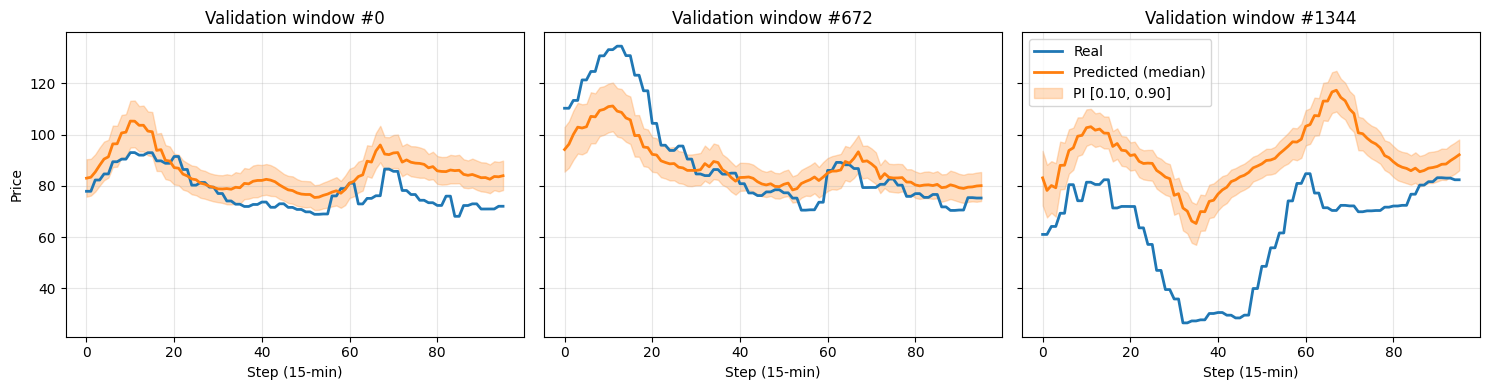

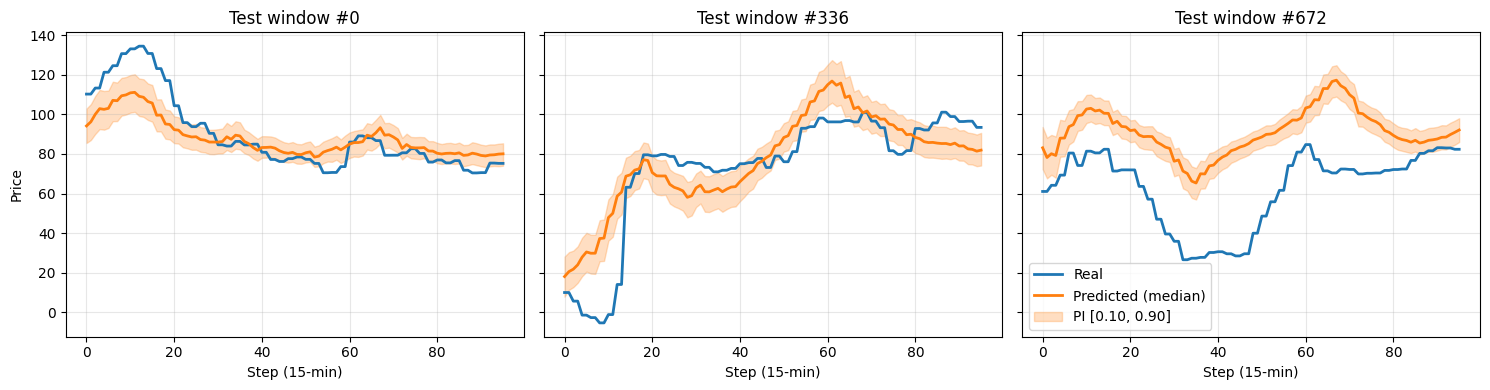

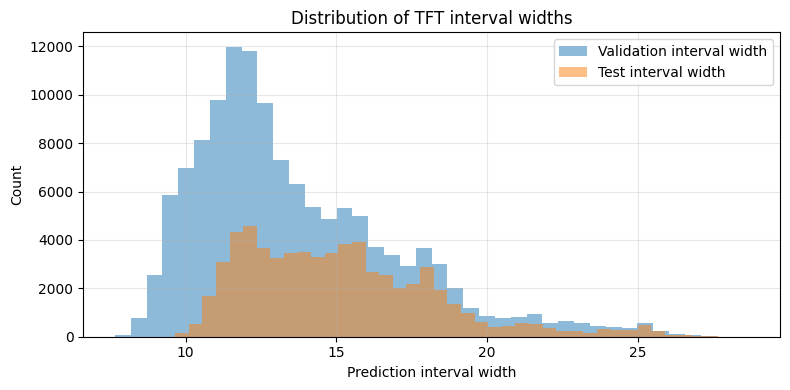

In [11]:
# Real vs predicted with TFT prediction intervals (quantiles)

def select_window_indices(n_windows: int, n_show: int = 3) -> list[int]:
    if n_windows <= n_show:
        return list(range(n_windows))
    return np.linspace(0, n_windows - 1, n_show, dtype=int).tolist()

# TFT quantiles used by QuantileLoss (matches output_size)
quantiles = [float(q) for q in tft.loss.quantiles]
q_array = np.array(quantiles, dtype=float)

def q_idx(q: float) -> int:
    return int(np.argmin(np.abs(q_array - q)))

idx_q10 = q_idx(0.10)
idx_q50 = q_idx(0.50)
idx_q90 = q_idx(0.90)
print(f"Using quantiles -> low: {quantiles[idx_q10]}, median: {quantiles[idx_q50]}, high: {quantiles[idx_q90]}")

# Full quantile predictions for interval plotting
val_q = raw_val["prediction"].detach().cpu().numpy()  # [n_windows, horizon, n_quantiles]
test_q = raw_test["prediction"].detach().cpu().numpy()

def plot_windows_with_intervals(
    y_true: np.ndarray,
    y_quantiles: np.ndarray,
    title_prefix: str,
    n_show: int = 3,
    low_idx: int = idx_q10,
    med_idx: int = idx_q50,
    high_idx: int = idx_q90,
) -> None:
    idxs = select_window_indices(len(y_true), n_show=n_show)
    horizon = np.arange(y_true.shape[1])

    fig, axes = plt.subplots(1, len(idxs), figsize=(5 * len(idxs), 4), sharey=True)
    if len(idxs) == 1:
        axes = [axes]

    for ax, idx in zip(axes, idxs):
        y_low = y_quantiles[idx, :, low_idx]
        y_med = y_quantiles[idx, :, med_idx]
        y_high = y_quantiles[idx, :, high_idx]

        ax.plot(horizon, y_true[idx], label="Real", linewidth=2, color="#1f77b4")
        ax.plot(horizon, y_med, label="Predicted (median)", linewidth=2, color="#ff7f0e")
        ax.fill_between(
            horizon,
            y_low,
            y_high,
            alpha=0.25,
            color="#ff7f0e",
            label=f"PI [{quantiles[low_idx]:.2f}, {quantiles[high_idx]:.2f}]"
        )

        ax.set_title(f"{title_prefix} window #{idx}")
        ax.set_xlabel("Step (15-min)")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Price")
    axes[-1].legend(loc="best")
    plt.tight_layout()
    plt.show()

# Validation and test interval plots
plot_windows_with_intervals(val_true, val_q, "Validation", n_show=3)
plot_windows_with_intervals(test_true, test_q, "Test", n_show=3)

# Aggregate uncertainty width diagnostics
val_width = (val_q[:, :, idx_q90] - val_q[:, :, idx_q10]).reshape(-1)
test_width = (test_q[:, :, idx_q90] - test_q[:, :, idx_q10]).reshape(-1)

plt.figure(figsize=(8, 4))
plt.hist(val_width, bins=40, alpha=0.5, label="Validation interval width")
plt.hist(test_width, bins=40, alpha=0.5, label="Test interval width")
plt.xlabel("Prediction interval width")
plt.ylabel("Count")
plt.title("Distribution of TFT interval widths")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Production note
For true day-ahead use, replace decoder weather values with **forecast weather** for the next 96 time steps.